In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
import matplotlib.pyplot as plt
import seaborn as sns
from palette import Palette

In [3]:
df_hitters = pd.read_csv("../data/hitters.csv")
df_hitters = df_hitters.dropna(subset=["Salary"]).copy()

df_hitters = pd.get_dummies(df_hitters, columns=['League', 'Division', 'NewLeague'],
                            drop_first=True, dtype=int)

X_raw = df_hitters.drop(columns=["Salary"])
y_raw = df_hitters["Salary"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
n, p = X_scaled.shape
feature_names = X_raw.columns.tolist()

y_log = np.log(y_raw)
y_mean = y_log.mean()
y_tilde = (y_log - y_mean).to_numpy()

print(f"Dataset shape: {df_hitters.shape}")
print(f"Predictors: {feature_names}")

Dataset shape: (263, 20)
Predictors: ['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists', 'Errors', 'League_N', 'Division_W', 'NewLeague_N']


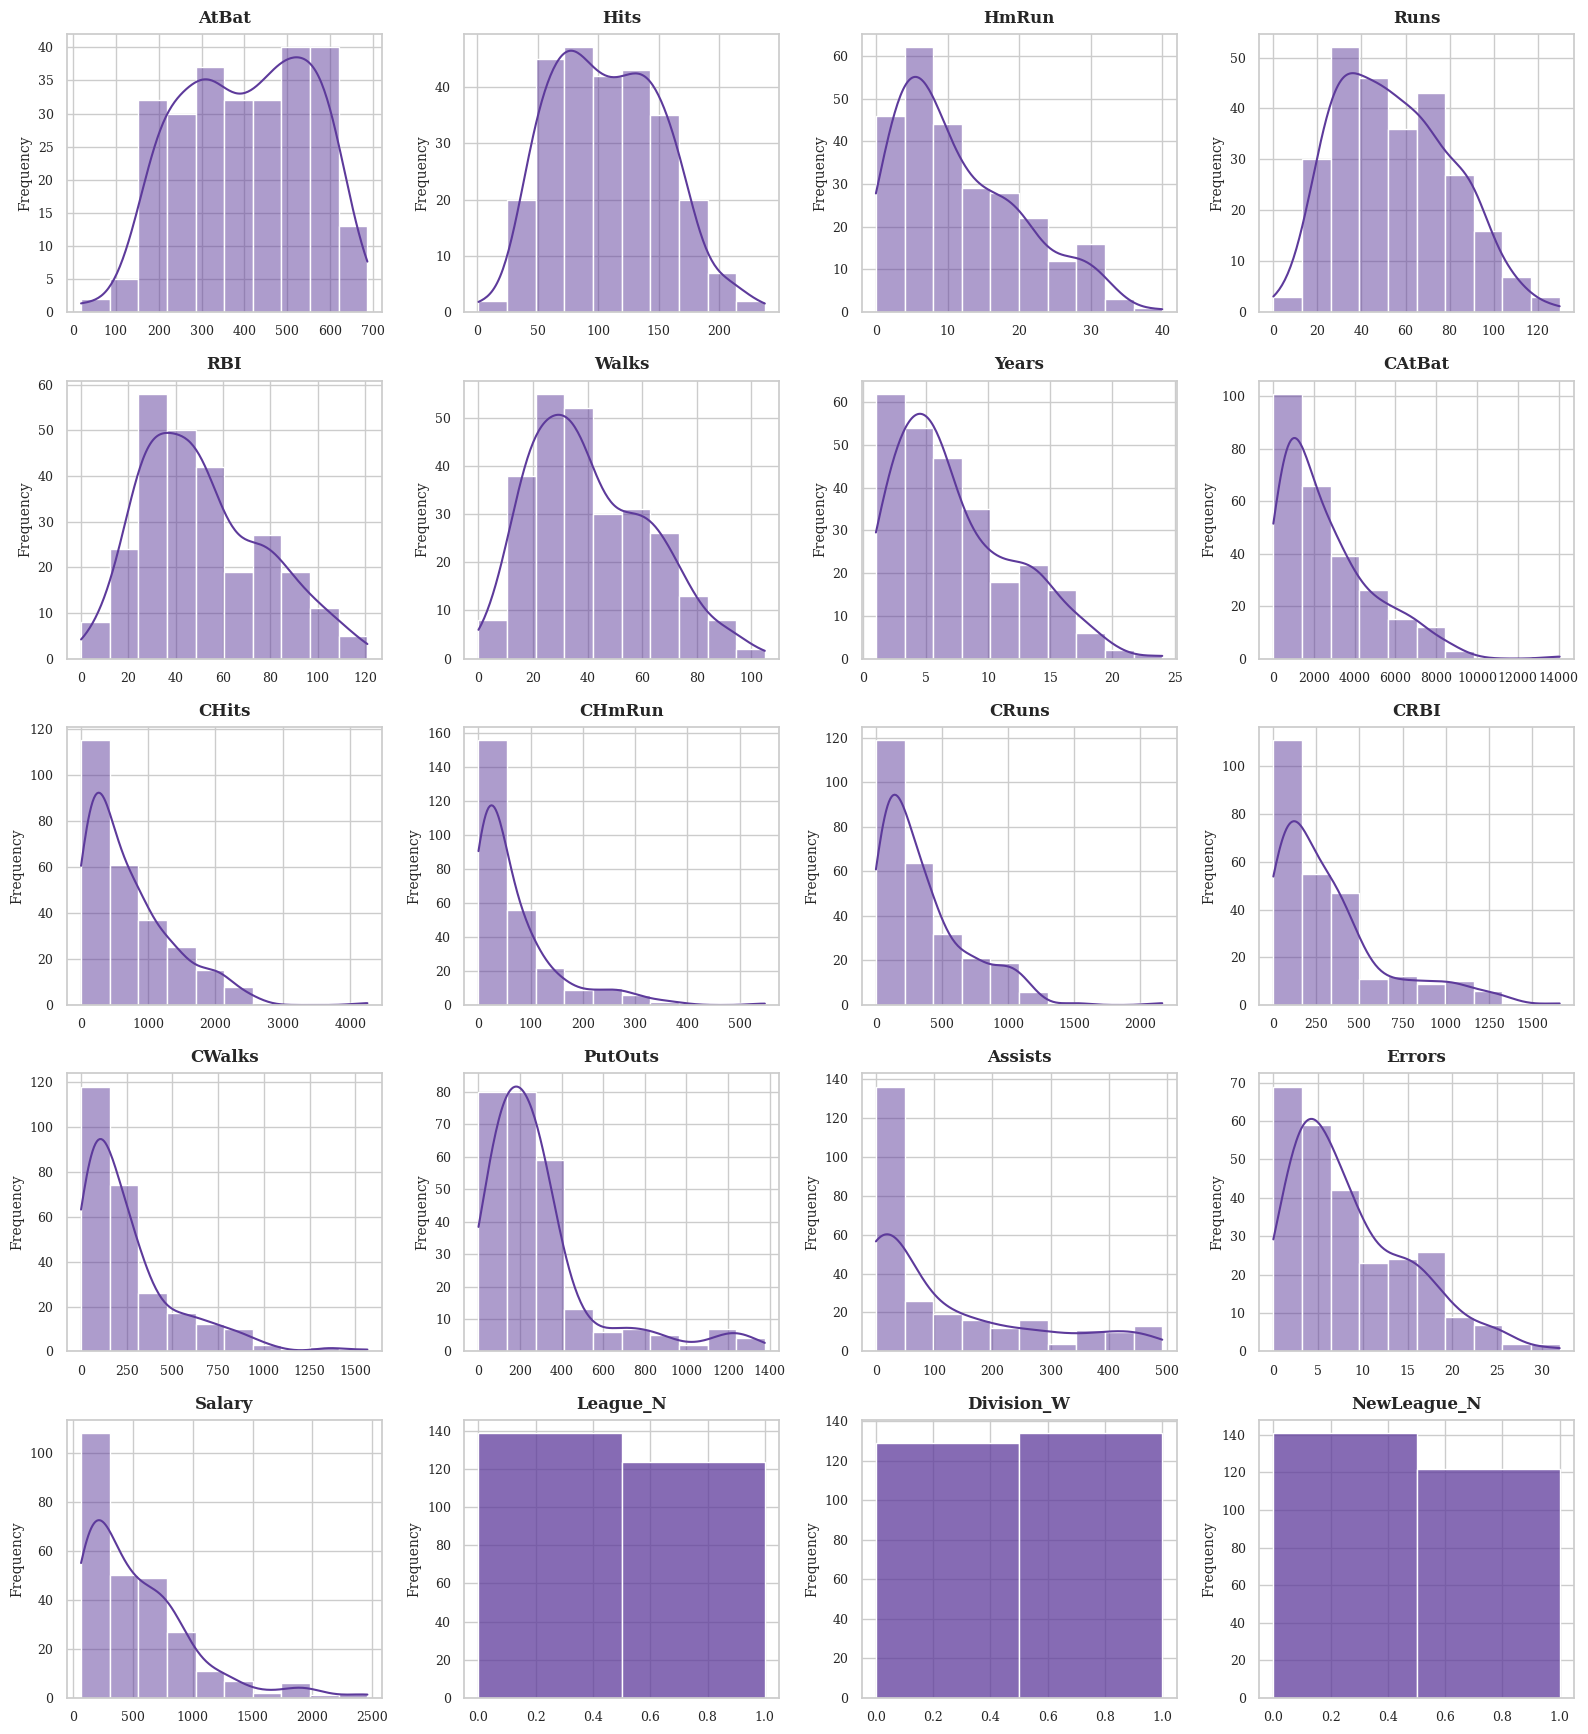

In [13]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

columns_to_plot = df_hitters.columns.tolist()
n_vars = len(columns_to_plot)

n_grid_cols = 4
n_grid_rows = math.ceil(n_vars / n_grid_cols)

sns.set_theme(style="whitegrid", font="serif")
fig, axes = plt.subplots(n_grid_rows, n_grid_cols, figsize=(16, 3.5 * n_grid_rows))
axes = axes.flatten()

for i, col_name in enumerate(columns_to_plot):
    is_binary = df_hitters[col_name].nunique() <= 2
    
    sns.histplot(
        data=df_hitters,
        x=col_name,
        kde=not is_binary,
        bins=10 if not is_binary else 2,
        color=Palette.lasso_hyp,
        ax=axes[i]
    )
    
    axes[i].set_title(col_name, fontsize=12, weight='bold', pad=8)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frequency", fontsize=10)
    axes[i].tick_params(axis='both', labelsize=9)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

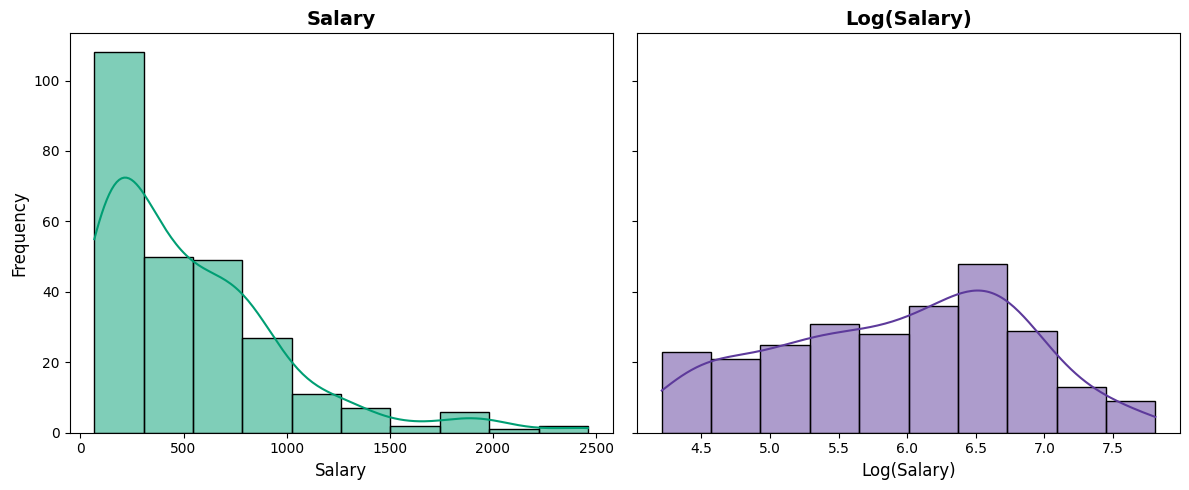

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

num_bins = 10

sns.histplot(y_raw, kde=True, bins=num_bins, color=Palette.gprior, ax=axes[0])
axes[0].set_title("Salary", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Salary", fontsize=12)
axes[0].set_ylabel("Frequency", fontsize=12)

sns.histplot(y_log, kde=True, bins=num_bins, color=Palette.ols, ax=axes[1])
axes[1].set_title("Log(Salary)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Log(Salary)", fontsize=12)
axes[1].set_ylabel("", fontsize=12)

plt.tight_layout()
plt.savefig("../graphics/hitters_salary_distribution.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [16]:
np.mean(y_log)

5.927221541221392

## Bayesian Lasso

In [5]:
from utils_lasso import bayesian_lasso_hyp

In [6]:
print("Calculating Empirical Bayes initialization (Park & Casella) via Normal Equations...")

XTX = X_scaled.T @ X_scaled
XTy = X_scaled.T @ y_tilde
beta_ols = np.linalg.solve(XTX, XTy)

y_pred_ols = X_scaled @ beta_ols
residuals_init = y_tilde - y_pred_ols
sigma2_ols = np.sum(residuals_init**2) / (n - p)

sum_abs_beta_ols = np.sum(np.abs(beta_ols))
lambda_0 = (p * np.sqrt(sigma2_ols)) / sum_abs_beta_ols
lambda_0_sq = lambda_0**2

print(f"Initial estimate (lambda_0): {lambda_0:.4f}")

r_prior = 1.0
delta_prior = 1.0 / lambda_0_sq

Calculating Empirical Bayes initialization (Park & Casella) via Normal Equations...
Initial estimate (lambda_0): 3.0542


In [7]:
print("Running Bayesian Lasso with hyperprior on lambda (Algorithm 3)...")
print(f"Configuration: T = 11000 iterations, Burn-in = 1000, Seed = 2026")

resultados = bayesian_lasso_hyp(
    y_tilde, X_scaled,
    r=r_prior, delta=delta_prior,
    T=11000, B=1000, random_seed=2026
)

# Posterior medians
betas_median = np.median(resultados['beta'], axis=0)
sigma2_median = np.median(resultados['sigma2'], axis=0)
lambda_sq_median = np.median(resultados['lambda_sq'], axis=0)

lambda_estimado = np.sqrt(lambda_sq_median)
sigma_estimado = np.sqrt(sigma2_median)

# Equivalent frequentist alpha
alpha_equivalente = (lambda_estimado * sigma_estimado) / n

# Classic Lasso with calibrated penalty
lasso_frec = Lasso(alpha=alpha_equivalente, fit_intercept=False,
                   max_iter=100000, tol=1e-5)
lasso_frec.fit(X_scaled, y_tilde)
betas_frecuentistas = lasso_frec.coef_

# Build comparison table
intercepto = y_mean

df_comparativa = pd.DataFrame({
    'Variable Predictora': ['Intercepto (Salario Base)'] + feature_names,
    'Bayesian Lasso (Mediana)': [intercepto] + list(betas_median),
    'Mixed Approach (Frecuentista)': [intercepto] + list(betas_frecuentistas)
})

print("\n" + "="*72)
print("         ESTIMACIÓN FINAL Y SELECCIÓN DE VARIABLES: DATASET HITTERS     ")
print("="*72)
print(df_comparativa.to_string(index=False, formatters={
    'Bayesian Lasso (Mediana)': '{:,.2f}'.format,
    'Mixed Approach (Frecuentista)': '{:,.2f}'.format
}))
print("-"*72)
print(f"Parámetro Lambda (\u03bb) estimado:  {lambda_estimado:.4f}")
print(f"Parámetro Sigma (\u03c3) estimado:   {sigma_estimado:.4f}")
print(f"Penalización Alpha (\u03b1) equivalente: {alpha_equivalente:.4f}")
print("========================================================================")

Running Bayesian Lasso with hyperprior on lambda (Algorithm 3)...
Configuration: T = 11000 iterations, Burn-in = 1000, Seed = 2026

         ESTIMACIÓN FINAL Y SELECCIÓN DE VARIABLES: DATASET HITTERS     
      Variable Predictora Bayesian Lasso (Mediana) Mixed Approach (Frecuentista)
Intercepto (Salario Base)                     5.93                          5.93
                    AtBat                    -0.07                         -0.00
                     Hits                     0.23                          0.23
                    HmRun                     0.02                          0.03
                     Runs                     0.05                          0.02
                      RBI                     0.01                          0.00
                    Walks                     0.11                          0.10
                    Years                     0.21                          0.23
                   CAtBat                     0.06                

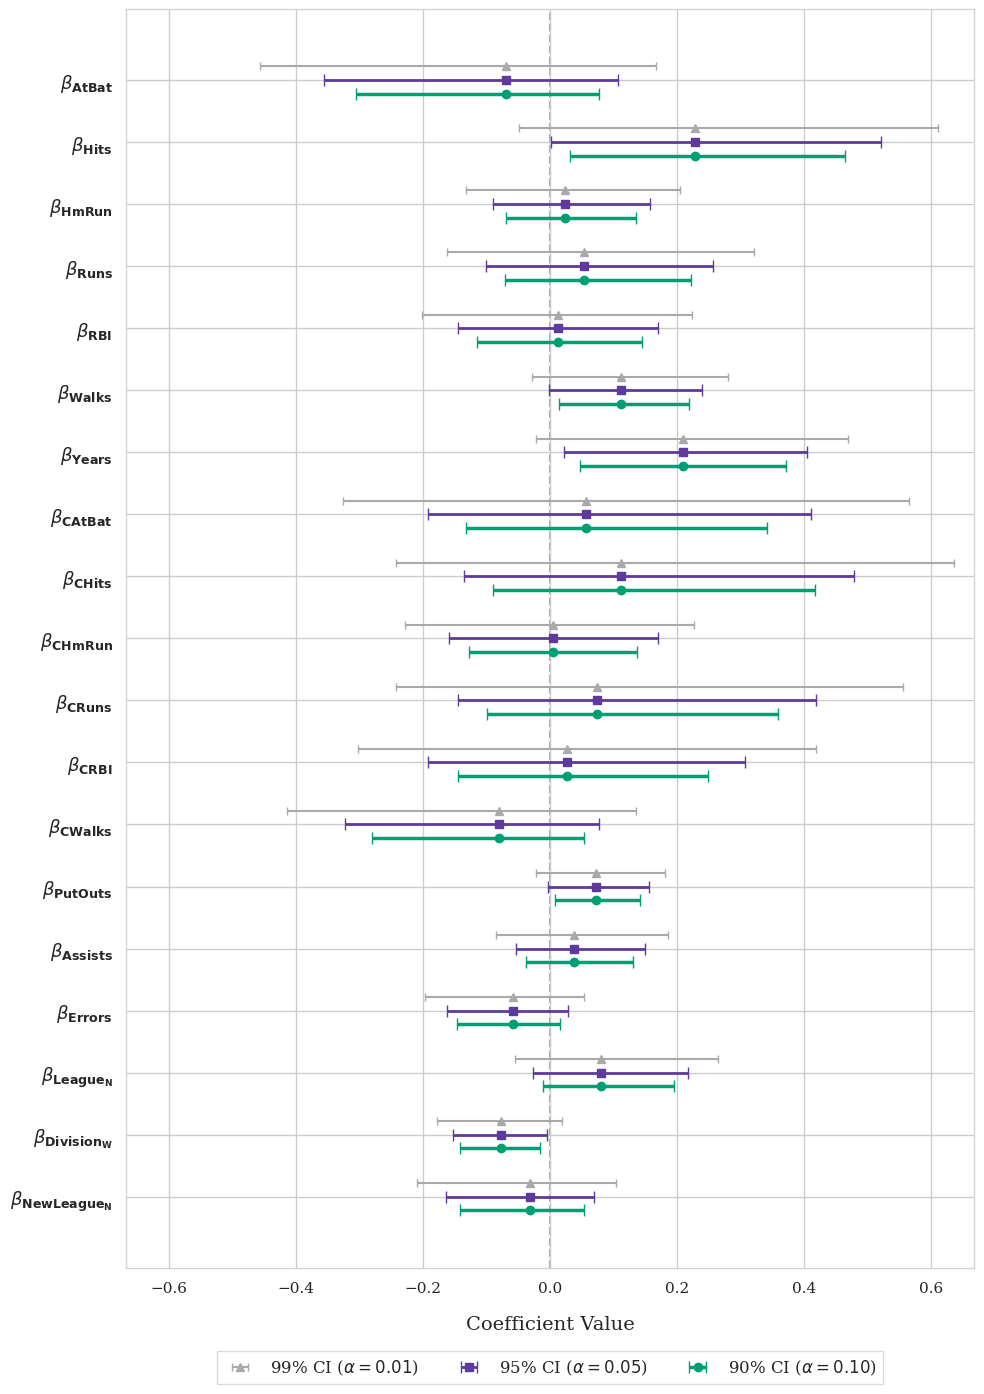

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

scaled_mcmc_betas = resultados['beta']
scaled_median = np.median(scaled_mcmc_betas, axis=0)

ci_90 = np.percentile(scaled_mcmc_betas, [5.0, 95.0], axis=0)
err_90 = np.abs(ci_90 - scaled_median)

ci_95 = np.percentile(scaled_mcmc_betas, [2.5, 97.5], axis=0)
err_95 = np.abs(ci_95 - scaled_median)

ci_99 = np.percentile(scaled_mcmc_betas, [0.5, 99.5], axis=0)
err_99 = np.abs(ci_99 - scaled_median)

sns.set_theme(style="whitegrid", font="serif")
fig, ax = plt.subplots(figsize=(10, 14))

p = scaled_median.shape[0]
y_pos = np.arange(p)
offset = 0.22

ax.errorbar(scaled_median, y_pos - offset, xerr=err_99, fmt='^',
            color="#A9A9A9", linewidth=1.5, capsize=3, markersize=6,
            label=r'99% CI ($\alpha=0.01$)')

ax.errorbar(scaled_median, y_pos, xerr=err_95, fmt='s',
            color=Palette.lasso_hyp, linewidth=2.0, capsize=4, markersize=6,
            label=r'95% CI ($\alpha=0.05$)')

ax.errorbar(scaled_median, y_pos + offset, xerr=err_90, fmt='o',
            color=Palette.aux3, linewidth=2.5, capsize=4, markersize=6,
            label=r'90% CI ($\alpha=0.10$)')

ax.axvline(0, color='#808080', linestyle='--', linewidth=1.5, alpha=0.7, zorder=0)

all_values = np.concatenate([scaled_median + err_99[1], scaled_median - err_99[0]])
max_abs = np.max(np.abs(all_values))
padding = 1.05
ax.set_xlim(-max_abs * padding, max_abs * padding)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('#D3D3D3')
    spine.set_linewidth(1.0)

ax.set_yticks(y_pos)
ax.set_yticklabels([rf"$\beta_{{\mathbf{{{name}}}}}$" for name in feature_names], fontsize=13)
ax.invert_yaxis()

ax.set_xlabel("Coefficient Value", fontsize=14, labelpad=15)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.06), ncol=3, fontsize=12,
          frameon=True, edgecolor='#D3D3D3', fancybox=False)

plt.tight_layout()
plt.savefig("../graphics/bayesian_lasso_hitters_hyp_ci.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [9]:
feature_names_array = np.array(feature_names)

mask_90 = (ci_90[0] > 0) | (ci_90[1] < 0)
selected_90 = feature_names_array[mask_90]

mask_95 = (ci_95[0] > 0) | (ci_95[1] < 0)
selected_95 = feature_names_array[mask_95]

mask_99 = (ci_99[0] > 0) | (ci_99[1] < 0)
selected_99 = feature_names_array[mask_99]

print("-" * 50)
print(" BAYESIAN VARIABLE SELECTION (CREDIBLE INTERVALS)")
print("-" * 50)
print(f"90% CI Selected ({len(selected_90)} variables):")
print(f"  {list(selected_90)}\n")
print(f"95% CI Selected ({len(selected_95)} variables):")
print(f"  {list(selected_95)}\n")
print(f"99% CI Selected ({len(selected_99)} variables):")
print(f"  {list(selected_99)}")
print("-" * 50)

--------------------------------------------------
 BAYESIAN VARIABLE SELECTION (CREDIBLE INTERVALS)
--------------------------------------------------
90% CI Selected (5 variables):
  ['Hits', 'Walks', 'Years', 'PutOuts', 'Division_W']

95% CI Selected (3 variables):
  ['Hits', 'Years', 'Division_W']

99% CI Selected (0 variables):
  []
--------------------------------------------------


In [10]:
import numpy as np
import pandas as pd

means_X = scaler.mean_
sigmas_X = scaler.scale_
unscaled_betas = betas_median / sigmas_X
unscaled_intercept = y_mean - np.sum(unscaled_betas * means_X)

df_unscaled = pd.DataFrame({
    'Predictor Variable': ['Intercept (Base Log-Salary)'] + feature_names,
    'True Unscaled Coefficient': [unscaled_intercept] + list(unscaled_betas)
})

print("=" * 70)
print("         TRUE RECONSTRUCTED COEFFICIENTS (UNSCALED LOG-SALARY SCALE)     ")
print("=" * 70)
print(df_unscaled.to_string(index=False, formatters={'True Unscaled Coefficient': '{:,.6f}'.format}))
print("=" * 70)

         TRUE RECONSTRUCTED COEFFICIENTS (UNSCALED LOG-SALARY SCALE)     
         Predictor Variable True Unscaled Coefficient
Intercept (Base Log-Salary)                  4.644040
                      AtBat                 -0.000468
                       Hits                  0.005057
                      HmRun                  0.002789
                       Runs                  0.002124
                        RBI                  0.000466
                      Walks                  0.005152
                      Years                  0.043650
                     CAtBat                  0.000025
                      CHits                  0.000173
                     CHmRun                  0.000054
                      CRuns                  0.000226
                       CRBI                  0.000084
                     CWalks                 -0.000302
                    PutOuts                  0.000260
                    Assists                  0.000259
        

In [12]:
import numpy as np
import pandas as pd

means_X = scaler.mean_
sigmas_X = scaler.scale_
unscaled_betas = betas_median / sigmas_X
unscaled_intercept = y_mean - np.sum(unscaled_betas * means_X)

real_baseline_salary = np.exp(unscaled_intercept)
multipliers = np.exp(unscaled_betas)
percentage_changes = (multipliers - 1) * 100

df_real_salary = pd.DataFrame({
    'Predictor Variable': feature_names,
    'Log Coefficient': unscaled_betas,
    'Multiplier (e^beta)': multipliers,
    'Percentage Impact (%)': percentage_changes
})

print("=" * 85)
print(f"Baseline Salary (All raw features = 0): ${real_baseline_salary:,.2f} thousand dollars")
print("=" * 85)
print(df_real_salary.to_string(index=False, formatters={
    'Log Coefficient': '{:,.6f}'.format,
    'Multiplier (e^beta)': '{:,.4f}'.format,
    'Percentage Impact (%)': '{:+.2f}%'.format
}))
print("=" * 85)

Baseline Salary (All raw features = 0): $103.96 thousand dollars
Predictor Variable Log Coefficient Multiplier (e^beta) Percentage Impact (%)
             AtBat       -0.000468              0.9995                -0.05%
              Hits        0.005057              1.0051                +0.51%
             HmRun        0.002789              1.0028                +0.28%
              Runs        0.002124              1.0021                +0.21%
               RBI        0.000466              1.0005                +0.05%
             Walks        0.005152              1.0052                +0.52%
             Years        0.043650              1.0446                +4.46%
            CAtBat        0.000025              1.0000                +0.00%
             CHits        0.000173              1.0002                +0.02%
            CHmRun        0.000054              1.0001                +0.01%
             CRuns        0.000226              1.0002                +0.02%
           

In [15]:
import numpy as np
import pandas as pd

means_X = scaler.mean_
sigmas_X = scaler.scale_
unscaled_betas = betas_median / sigmas_X
unscaled_intercept = y_mean - np.sum(unscaled_betas * means_X)

real_baseline_salary = np.exp(unscaled_intercept)
multipliers = np.exp(unscaled_betas)
percentage_changes = (multipliers - 1) * 100

df_real_salary = pd.DataFrame({
    'Predictor Variable': feature_names,
    'Standardised Coef': betas_median,
    'Log Coefficient': unscaled_betas,
    'Multiplier (e^beta)': multipliers,
    'Percentage Impact (%)': percentage_changes
})

print("=" * 105)
print(f"Baseline Salary (All raw features = 0): ${real_baseline_salary:,.2f} thousand dollars")
print("=" * 105)
print(df_real_salary.to_string(index=False, formatters={
    'Standardised Coef': '{:,.4f}'.format,
    'Log Coefficient': '{:,.6f}'.format,
    'Multiplier (e^beta)': '{:,.4f}'.format,
    'Percentage Impact (%)': '{:+.2f}%'.format
}))
print("=" * 105)

Baseline Salary (All raw features = 0): $103.96 thousand dollars
Predictor Variable Standardised Coef Log Coefficient Multiplier (e^beta) Percentage Impact (%)
             AtBat           -0.0688       -0.000468              0.9995                -0.05%
              Hits            0.2278        0.005057              1.0051                +0.51%
             HmRun            0.0244        0.002789              1.0028                +0.28%
              Runs            0.0541        0.002124              1.0021                +0.21%
               RBI            0.0120        0.000466              1.0005                +0.05%
             Walks            0.1117        0.005152              1.0052                +0.52%
             Years            0.2088        0.043650              1.0446                +4.46%
            CAtBat            0.0561        0.000025              1.0000                +0.00%
             CHits            0.1119        0.000173              1.0002        

#### <b> beta_0 for 3-variables model

In [18]:
idx_hits = feature_names.index('Hits')
idx_years = feature_names.index('Years')
idx_div = feature_names.index('Division_W')

truncated_sum = (
    unscaled_betas[idx_hits] * scaler.mean_[idx_hits] +
    unscaled_betas[idx_years] * scaler.mean_[idx_years] +
    unscaled_betas[idx_div] * scaler.mean_[idx_div]
)

beta_0_truncated = y_mean - truncated_sum
print(f"Truncated 3-Variable Intercept: {beta_0_truncated:.4f}")
print(f"Corresponding Baseline Salary: ${np.exp(beta_0_truncated):.2f} thousand dollars")

Truncated 3-Variable Intercept: 5.1417
Corresponding Baseline Salary: $171.00 thousand dollars


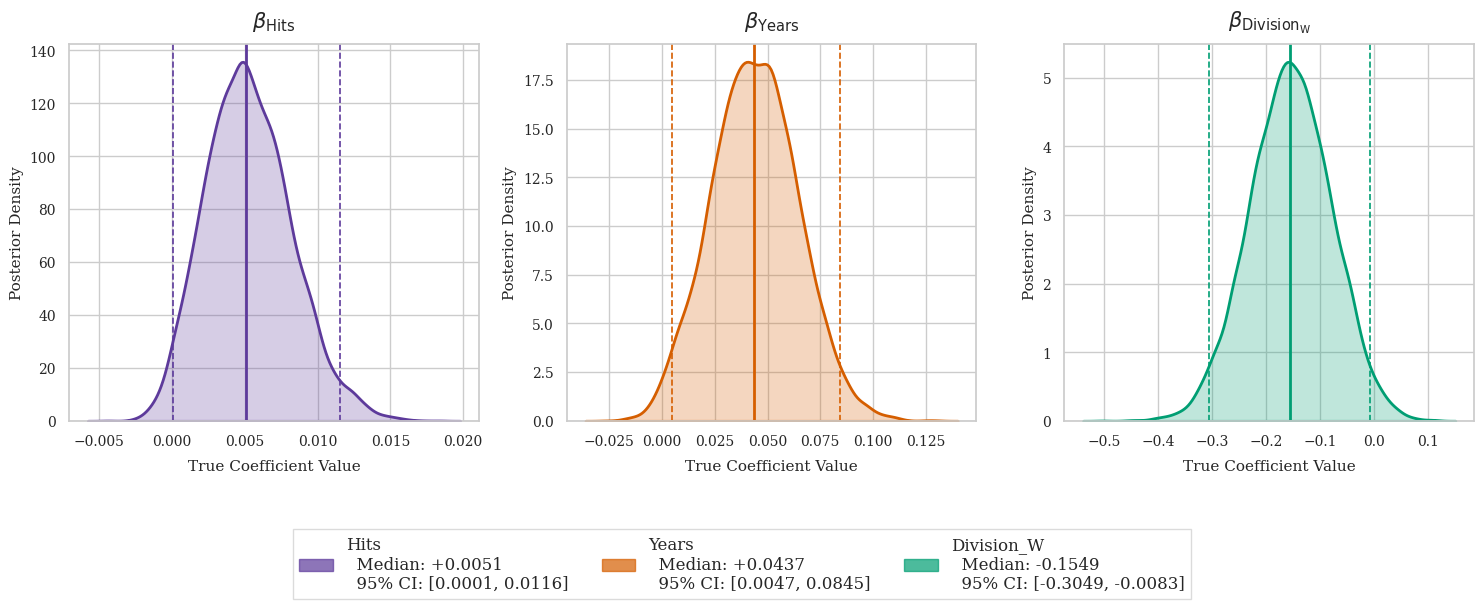

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

target_features = ['Hits', 'Years', 'Division_W']
indices = [feature_names.index(var) for var in target_features]
sigmas_target = scaler.scale_[indices]

unscaled_chains = resultados['beta'][:, indices] / sigmas_target

colors = [Palette.aux1, Palette.aux2, Palette.aux3]
latex_labels = [r'$\beta_{\text{Hits}}$', r'$\beta_{\text{Years}}$', r'$\beta_{\text{Division}_{\text{W}}}$']

sns.set_theme(style="whitegrid", font="serif")
fig, axes = plt.subplots(1, 3, figsize=(15, 5.0))

legend_handles = []

for i, var_name in enumerate(target_features):
    ax = axes[i]
    chain_unscaled = unscaled_chains[:, i]
    current_color = colors[i]

    median_val = np.median(chain_unscaled)
    ci_lower, ci_upper = np.percentile(chain_unscaled, [2.5, 97.5])

    sns.kdeplot(
        x=chain_unscaled, ax=ax, fill=True,
        color=current_color, alpha=0.25, linewidth=2
    )

    ax.axvline(median_val, color=current_color, linestyle='-', linewidth=2)
    ax.axvline(ci_lower, color=current_color, linestyle='--', linewidth=1.2)
    ax.axvline(ci_upper, color=current_color, linestyle='--', linewidth=1.2)

    ax.set_title(latex_labels[i], fontsize=15, pad=12)
    ax.set_xlabel('True Coefficient Value', fontsize=11, labelpad=8)
    ax.set_ylabel('Posterior Density', fontsize=11)
    ax.tick_params(axis='both', labelsize=10)

    label_text = (
        f"{var_name}\n"
        f"  Median estimate: {median_val:.4f}\n"
    )
    patch = mpatches.Patch(color=current_color, alpha=0.7, label=label_text)
    legend_handles.append(patch)

fig.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, -0.06), ncol=3, fontsize=14,
           frameon=True, edgecolor='#D3D3D3', fancybox=False)

plt.tight_layout()
plt.savefig("../graphics/bayesian_lasso_hitters_3vars.pdf", format="pdf", bbox_inches="tight")
plt.show()